In [2]:
import pandas as pd
import re

def parse_can_log(file_path):
    """Parse CAN log file and return a pandas DataFrame"""
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Extract fields using regex
            match = re.search(r'Timestamp:\s([\d.]+)\s+ID:\s(\w+)\s+(\w+)\s+DLC:\s(\d+)\s+(.*)', line)
            if match:
                timestamp, can_id, flags, dlc, hex_data = match.groups()
                data.append({
                    'Timestamp': float(timestamp),
                    'ID': can_id,
                    'Flags': flags,
                    'DLC': int(dlc),
                    'Data': hex_data.strip()
                })
    
    df = pd.DataFrame(data)
    return df

# Usage
df = parse_can_log(r'C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\datasets\HCRL original\normal_run_data\normal_run_data.txt')
df["Attack"] = "R"
print(df)

           Timestamp    ID Flags  DLC                     Data Attack
0       1.479121e+09  0350   000    8  05 28 84 66 6d 00 00 a2      R
1       1.479121e+09  02c0   000    8  14 00 00 00 00 00 00 00      R
2       1.479121e+09  0430   000    8  00 00 00 00 00 00 00 00      R
3       1.479121e+09  04b1   000    8  00 00 00 00 00 00 00 00      R
4       1.479121e+09  01f1   000    8  00 00 00 00 00 00 00 00      R
...              ...   ...   ...  ...                      ...    ...
988866  1.479122e+09  02b0   000    5           ac 05 0c 07 7f      R
988867  1.479122e+09  0316   000    8  05 38 10 0c 38 28 01 7a      R
988868  1.479122e+09  018f   000    8  fe 31 00 00 00 4b 00 00      R
988869  1.479122e+09  0260   000    8  32 38 39 30 ff 93 59 1c      R
988870  1.479122e+09  02a0   000    8  20 00 75 1d 01 04 dd 00      R

[988871 rows x 6 columns]


In [3]:
def parse_can_csv(file_path):
    df_can = pd.read_csv(file_path, skipinitialspace=True)

    if 'ID dlc' in df_can.columns:
        df_can[['ID', 'DLC']] = df_can['ID dlc'].astype(str).str.split(r'\s+', n=1, expand=True)
        df_can = df_can.drop(columns=['ID dlc'])
    elif set(['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','attack/nonattack']).issubset(df_can.columns):
        df_can = df_can.rename(columns={'attack/nonattack': 'Attack'})
    else:
        names = ['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','Attack']
        df_can = pd.read_csv(file_path, header=None, names=names, skipinitialspace=True)

    unnamed = [c for c in df_can.columns if isinstance(c, str) and c.startswith('Unnamed')]
    if 'Attack' not in df_can.columns and unnamed:
        df_can = df_can.rename(columns={unnamed[-1]: 'Attack'})

    data_cols = sorted(
        [c for c in df_can.columns if isinstance(c, str) and c.lower().startswith('data')],
        key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0
    )

    def build_data(row):
        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        values = []
        for col in data_cols[:min(dlc, len(data_cols))]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            values.append(s)

        return ' '.join(values).strip()

    def infer_attack(row):
        attack = row.get('Attack')
        if isinstance(attack, str) and attack.strip():
            return attack

        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        for col in data_cols[min(dlc, len(data_cols)):]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            if not re.fullmatch(r'[0-9A-Fa-f]{2}', s):
                return s

        return pd.NA

    if data_cols:
        df_can['Data'] = df_can.apply(build_data, axis=1)
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA
        df_can['Attack'] = df_can.apply(infer_attack, axis=1).combine_first(df_can['Attack'])
    else:
        df_can['Data'] = df_can.get('Data', '').astype(str).str.strip()
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA

    df_can['Timestamp'] = pd.to_numeric(df_can['Timestamp'], errors='coerce')
    df_can['DLC'] = pd.to_numeric(df_can['DLC'], errors='coerce').astype('Int64')

    return df_can[['Timestamp','ID','DLC','Data','Attack']]

In [4]:
import numpy as np

def sliding_windows_id_data(df, window_size=8, step=2, attack_label='T'):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)
    attack = df['Attack'].to_numpy(dtype=object)

    n = len(df)
    num_windows = (n - window_size) // step + 1
    windows = []
    window_labels = []

    for start in range(0, n - window_size + 1, step):
        end = start + window_size
        windows.append(np.column_stack((ids[start:end], data[start:end])))
        window_labels.append(attack_label if 'T' in attack[start:end] else 'R')

    return windows, np.array(window_labels, dtype=object)


In [5]:
windowed_id_data0, window_attack_labels0 = sliding_windows_id_data(df, attack_label='D')


In [6]:
df_DoS = parse_can_csv(r'C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\datasets\HCRL original\DoS_dataset.csv')
print(df_DoS.head())
windowed_id_data1, window_attack_labels1 = sliding_windows_id_data(df_DoS, attack_label='D')

del df_DoS

      Timestamp    ID  DLC                     Data Attack
0  1.478198e+09  0316    8  05 21 68 09 21 21 00 6f      R
1  1.478198e+09  018f    8  fe 5b 00 00 00 3c 00 00      R
2  1.478198e+09  0260    8  19 21 22 30 08 8e 6d 3a      R
3  1.478198e+09  02a0    8  64 00 9a 1d 97 02 bd 00      R
4  1.478198e+09  0329    8  40 bb 7f 14 11 20 00 14      R


In [7]:
df_Fuzzy = parse_can_csv(r'C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\datasets\HCRL original\Fuzzy_dataset.csv')
print(df_Fuzzy.head())
windowed_id_data2, window_attack_labels2 = sliding_windows_id_data(df_Fuzzy, attack_label='F')

del df_Fuzzy

      Timestamp    ID  DLC                     Data Attack
0  1.478196e+09  0545    8  d8 00 00 8a 00 00 00 00      R
1  1.478196e+09  02b0    5           ff 7f 00 05 49      R
2  1.478196e+09  0002    8  00 00 00 00 00 01 07 15      R
3  1.478196e+09  0153    8  00 21 10 ff 00 ff 00 00      R
4  1.478196e+09  0130    8  19 80 00 ff fe 7f 07 60      R


In [8]:
df_gear = parse_can_csv(r'C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\datasets\HCRL original\gear_dataset.csv')
print(df_gear.head())
windowed_id_data3, window_attack_labels3 = sliding_windows_id_data(df_gear, attack_label='S')

del df_gear

      Timestamp    ID  DLC                     Data Attack
0  1.478193e+09  0140    8  00 00 00 00 10 29 2a 24      R
1  1.478193e+09  02c0    8  15 00 00 00 00 00 00 00      R
2  1.478193e+09  0350    8  05 20 44 68 77 00 00 7e      R
3  1.478193e+09  0370    8  00 20 00 00 00 00 00 00      R
4  1.478193e+09  043f    8  10 40 60 ff 78 c4 08 00      R


In [9]:
df_RPM = parse_can_csv(r'C:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\datasets\HCRL original\RPM_dataset.csv')
print(df_RPM.head())
windowed_id_data4, window_attack_labels4 = sliding_windows_id_data(df_RPM, attack_label='S')

del df_RPM

      Timestamp    ID  DLC                     Data Attack
0  1.478191e+09  0316    8  05 22 68 09 22 20 00 75      R
1  1.478191e+09  018f    8  fe 3b 00 00 00 3c 00 00      R
2  1.478191e+09  0260    8  19 22 22 30 ff 8f 6e 3f      R
3  1.478191e+09  02a0    8  60 00 83 1d 96 02 bd 00      R
4  1.478191e+09  0329    8  dc b8 7e 14 11 20 00 14      R


In [10]:
# merge windowed datasets into the single variables used by downstream cells
windowed_id_data = []
windowed_id_data.extend(windowed_id_data0[int(len(windowed_id_data0)*0.2):])
windowed_id_data.extend(windowed_id_data1[int(len(windowed_id_data1)*0.2):])
windowed_id_data.extend(windowed_id_data2[int(len(windowed_id_data2)*0.2):])
windowed_id_data.extend(windowed_id_data3[int(len(windowed_id_data3)*0.2):])
windowed_id_data.extend(windowed_id_data4[int(len(windowed_id_data4)*0.2):])

windowed_id_data_test = []
windowed_id_data_test.extend(windowed_id_data0[:int(len(windowed_id_data0)*0.2)])
windowed_id_data_test.extend(windowed_id_data1[:int(len(windowed_id_data1)*0.2)])
windowed_id_data_test.extend(windowed_id_data2[:int(len(windowed_id_data2)*0.2)])
windowed_id_data_test.extend(windowed_id_data3[:int(len(windowed_id_data3)*0.2)])
windowed_id_data_test.extend(windowed_id_data4[:int(len(windowed_id_data4)*0.2)])

window_attack_labels = np.concatenate([
    window_attack_labels0[int(len(windowed_id_data0)*0.2):],
    window_attack_labels1[int(len(windowed_id_data1)*0.2):],
    window_attack_labels2[int(len(windowed_id_data2)*0.2):],
    window_attack_labels3[int(len(windowed_id_data3)*0.2):],
    window_attack_labels4[int(len(windowed_id_data4)*0.2):]
])

window_attack_labels_test = np.concatenate([
    window_attack_labels0[:int(len(windowed_id_data0)*0.2)],
    window_attack_labels1[:int(len(windowed_id_data1)*0.2)],
    window_attack_labels2[:int(len(windowed_id_data2)*0.2)],
    window_attack_labels3[:int(len(windowed_id_data3)*0.2)],
    window_attack_labels4[:int(len(windowed_id_data4)*0.2)]
])

print("merged windows:", len(windowed_id_data), "merged labels:", window_attack_labels.shape)

merged windows: 7023328 merged labels: (7023328,)


In [11]:
print(len(windowed_id_data), windowed_id_data[:10])

7023328 [array([['0130', 'fd 7e 00 ff 6d 7f 01 4c'],
       ['0131', '77 80 00 00 42 7e 01 96'],
       ['0140', '00 00 00 00 0e 25 21 8d'],
       ['0316', '05 27 7c 0b 27 20 0b 7c'],
       ['018f', 'fe 2d 00 00 00 4d 00 00'],
       ['0260', '20 27 25 30 ff 93 5d 0b'],
       ['02a0', '00 00 6b 1d 01 04 dd 00'],
       ['0329', '40 b9 7f 14 11 20 00 14']], dtype=object), array([['0140', '00 00 00 00 0e 25 21 8d'],
       ['0316', '05 27 7c 0b 27 20 0b 7c'],
       ['018f', 'fe 2d 00 00 00 4d 00 00'],
       ['0260', '20 27 25 30 ff 93 5d 0b'],
       ['02a0', '00 00 6b 1d 01 04 dd 00'],
       ['0329', '40 b9 7f 14 11 20 00 14'],
       ['0350', '05 28 c4 66 6a 00 00 e5'],
       ['0545', 'd8 00 00 8d 00 00 00 00']], dtype=object), array([['018f', 'fe 2d 00 00 00 4d 00 00'],
       ['0260', '20 27 25 30 ff 93 5d 0b'],
       ['02a0', '00 00 6b 1d 01 04 dd 00'],
       ['0329', '40 b9 7f 14 11 20 00 14'],
       ['0350', '05 28 c4 66 6a 00 00 e5'],
       ['0545', 'd8 00 00 8d 00 00 

In [12]:
def _hex_byte_list_from_row(row):
    msg_id, data = row
    msg_id = str(msg_id).strip()
    if len(msg_id) % 2 != 0:
        msg_id = '0' + msg_id
    id_bytes = [msg_id[i:i+2] for i in range(0, len(msg_id), 2)]
    data_bytes = [b for b in str(data).split() if b]
    return [int(b, 16) for b in id_bytes + data_bytes]

def convert_windowed_id_data_to_ints(windowed_data, pad_value=0):
    int_windows = []
    for window in windowed_data:
        rows = [_hex_byte_list_from_row(row) for row in window]
        max_len = max(len(r) for r in rows)
        padded_rows = [r + [pad_value] * (max_len - len(r)) for r in rows]
        int_windows.append(np.array(padded_rows, dtype=np.uint8))
    return int_windows

int_windowed_id_data = convert_windowed_id_data_to_ints(windowed_id_data)
int_windowed_id_data_test = convert_windowed_id_data_to_ints(windowed_id_data_test)

print(int_windowed_id_data[0].shape)
print(int_windowed_id_data[0][:2])

(8, 10)
[[  1  48 253 126   0 255 109 127   1  76]
 [  1  49 119 128   0   0  66 126   1 150]]


In [13]:
int_windowed_id_data

[array([[  1,  48, 253, 126,   0, 255, 109, 127,   1,  76],
        [  1,  49, 119, 128,   0,   0,  66, 126,   1, 150],
        [  1,  64,   0,   0,   0,   0,  14,  37,  33, 141],
        [  3,  22,   5,  39, 124,  11,  39,  32,  11, 124],
        [  1, 143, 254,  45,   0,   0,   0,  77,   0,   0],
        [  2,  96,  32,  39,  37,  48, 255, 147,  93,  11],
        [  2, 160,   0,   0, 107,  29,   1,   4, 221,   0],
        [  3,  41,  64, 185, 127,  20,  17,  32,   0,  20]], dtype=uint8),
 array([[  1,  64,   0,   0,   0,   0,  14,  37,  33, 141],
        [  3,  22,   5,  39, 124,  11,  39,  32,  11, 124],
        [  1, 143, 254,  45,   0,   0,   0,  77,   0,   0],
        [  2,  96,  32,  39,  37,  48, 255, 147,  93,  11],
        [  2, 160,   0,   0, 107,  29,   1,   4, 221,   0],
        [  3,  41,  64, 185, 127,  20,  17,  32,   0,  20],
        [  3,  80,   5,  40, 196, 102, 106,   0,   0, 229],
        [  5,  69, 216,   0,   0, 141,   0,   0,   0,   0]], dtype=uint8),
 array([[ 

In [14]:
"""flattened_int_windowed_id_data = [window.ravel() for window in int_windowed_id_data]

# verify each window flattened to 80 bytes
assert all(arr.size == 80 for arr in flattened_int_windowed_id_data)

print(flattened_int_windowed_id_data[0].shape)
print(flattened_int_windowed_id_data[0])"""

'flattened_int_windowed_id_data = [window.ravel() for window in int_windowed_id_data]\n\n# verify each window flattened to 80 bytes\nassert all(arr.size == 80 for arr in flattened_int_windowed_id_data)\n\nprint(flattened_int_windowed_id_data[0].shape)\nprint(flattened_int_windowed_id_data[0])'

In [21]:
window_attack_onehot = np.zeros((len(window_attack_labels), 4), dtype=np.uint8)
window_attack_onehot[window_attack_labels == 'R', 0] = 1
window_attack_onehot[window_attack_labels == 'D', 1] = 1
window_attack_onehot[window_attack_labels == 'F', 2] = 1
window_attack_onehot[window_attack_labels == 'S', 3] = 1

print(window_attack_onehot[:10])

window_attack_onehot_test = np.zeros((len(window_attack_labels_test), 4), dtype=np.uint8)
window_attack_onehot_test[window_attack_labels_test == 'R', 0] = 1
window_attack_onehot_test[window_attack_labels_test == 'D', 1] = 1
window_attack_onehot_test[window_attack_labels_test == 'F', 2] = 1
window_attack_onehot_test[window_attack_labels_test == 'S', 3] = 1

print(window_attack_onehot_test[:])

[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]
[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 ...
 [0 0 0 1]
 [0 0 0 1]
 [0 0 0 1]]


In [16]:
#len(flattened_int_windowed_id_data)

In [17]:
len(window_attack_onehot)

7023328

In [18]:
int_windowed_id_data, window_attack_onehot = np.array(int_windowed_id_data), np.array(window_attack_onehot)
int_windowed_id_data_test, window_attack_onehot_test = np.array(int_windowed_id_data_test), np.array(window_attack_onehot_test)

In [22]:
window_attack_onehot.shape

(7023328, 4)

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(8,10)), 
    Dense(64, activation="sigmoid"), 
    Dense(32, activation='sigmoid'), 
    Dense(4, activation='softmax'),  
])

c:\Users\nb0801\Documents\GitHub\IDS-CAN-Bus-In-Vehicle-Networks-Based-on-the-Statistical-Characteristics-of-Attacks\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(int_windowed_id_data, window_attack_onehot, epochs=10, 
          batch_size=2000, 
          validation_split=0.2)
          
print(mod)

Epoch 1/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9365 - loss: 0.1952 - val_accuracy: 0.9658 - val_loss: 0.1018
Epoch 2/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9767 - loss: 0.0732 - val_accuracy: 0.9813 - val_loss: 0.0567
Epoch 3/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9821 - loss: 0.0564 - val_accuracy: 0.9870 - val_loss: 0.0397
Epoch 4/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9854 - loss: 0.0463 - val_accuracy: 0.9912 - val_loss: 0.0275
Epoch 5/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9876 - loss: 0.0397 - val_accuracy: 0.9941 - val_loss: 0.0199
Epoch 6/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9892 - loss: 0.0350 - val_accuracy: 0.9943 - val_loss: 0.0200
Epoch 7/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9905 - loss: 0.0312 - val_accuracy: 0.9950 - val_loss: 0.0175
Epoch 8/10
2810/2810 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9914 - loss: 0.0280 - 

In [25]:
loss, accuracy = model.evaluate(int_windowed_id_data_test, window_attack_onehot_test, verbose=0)
print(f"Test loss: {loss:.4f}")
print(f"Test accuracy: {accuracy:.4f}")

Test loss: 0.0310
Test accuracy: 0.9906


In [26]:
label_map = np.array(['R', 'D', 'F', 'S'])

def onehot_to_labels(onehot):
    return label_map[np.argmax(onehot, axis=1)]

recovered_labels = onehot_to_labels(model.predict(int_windowed_id_data_test))
print(recovered_labels[:20])

54870/54870 ━━━━━━━━━━━━━━━━━━━━ 39s 712us/step
['R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'R']


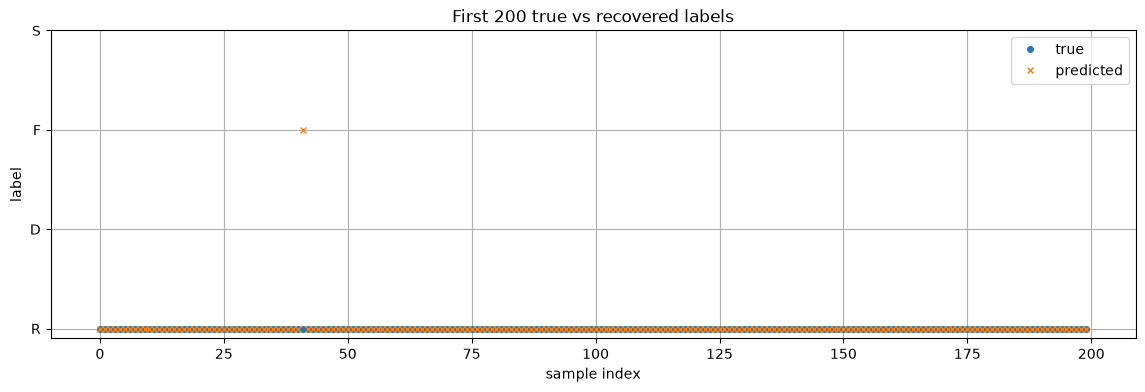

In [27]:
true_labels = onehot_to_labels(window_attack_onehot_test)
pred_labels = recovered_labels

n = min(200, len(true_labels))
label_to_num = {label: i for i, label in enumerate(label_map)}

true_nums = [label_to_num[label] for label in true_labels[:n]]
pred_nums = [label_to_num[label] for label in pred_labels[:n]]

plt.figure(figsize=(14, 4))
plt.plot(true_nums, label='true', marker='o', linestyle='None', markersize=4)
plt.plot(pred_nums, label='predicted', marker='x', linestyle='None', markersize=4)
plt.yticks(range(len(label_map)), label_map)
plt.xlabel('sample index')
plt.ylabel('label')
plt.title(f'First {n} true vs recovered labels')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

y_pred_probs = model.predict(int_windowed_id_data_test)
y_pred = onehot_to_labels(y_pred_probs)
y_true = onehot_to_labels(window_attack_onehot_test)

report = classification_report(
    y_true,
    y_pred,
    labels=label_map,
    target_names=label_map,
    zero_division=0,
)

cm = confusion_matrix(y_true, y_pred, labels=label_map)

tps = np.diag(cm)
fps = cm.sum(axis=0) - tps
fns = cm.sum(axis=1) - tps
tns = cm.sum() - (tps + fps + fns)

fpr = np.divide(fps, fps + tns, out=np.zeros_like(fps, dtype=float), where=(fps + tns) != 0)
fnr = np.divide(fns, fns + tps, out=np.zeros_like(fns, dtype=float), where=(fns + tps) != 0)

print("Classification report:")
print(report)
print("Confusion matrix:")
print(cm)

precision = precision_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
recall = recall_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)
f1 = f1_score(y_true, y_pred, labels=label_map, average=None, zero_division=0)

for label, p, r, f, fp_rate, fn_rate in zip(label_map, precision, recall, f1, fpr, fnr):
    print(
        f"{label}: precision={p:.4f}, recall={r:.4f}, "
        f"f1={f:.4f}, false positive rate={fp_rate:.4f}, false negative rate={fn_rate:.4f}"
    )

54870/54870 ━━━━━━━━━━━━━━━━━━━━ 40s 724us/step
Classification report:
              precision    recall  f1-score   support

           R       0.99      1.00      0.99    957983
           D       1.00      1.00      1.00    146141
           F       0.99      0.93      0.96    175955
           S       1.00      1.00      1.00    475750

    accuracy                           0.99   1755829
   macro avg       0.99      0.98      0.99   1755829
weighted avg       0.99      0.99      0.99   1755829

Confusion matrix:
[[955128     57   2298    500]
 [   183 145826     67     65]
 [ 11558     71 164254     72]
 [  1543     25    107 474075]]
R: precision=0.9863, recall=0.9970, f1=0.9916, false positive rate=0.0166, false negative rate=0.0030
D: precision=0.9990, recall=0.9978, f1=0.9984, false positive rate=0.0001, false negative rate=0.0022
F: precision=0.9852, recall=0.9335, f1=0.9586, false positive rate=0.0016, false negative rate=0.0665
S: precision=0.9987, recall=0.9965, f1=0.9976

In [29]:
import os
from tensorflow import keras

os.makedirs("saved_models", exist_ok=True)
model.save(os.path.join("saved_models", "HCRL_model.h5"))
print("Saved model to saved_models/HCRL_model.h5")

Saved model to saved_models/HCRL_model.h5
